# Interpretable Regression on the Medical Insurance Dataset 🏥, Powered by trust-free

This notebook demonstrates **trust-free**, the Python implementation of the PRICAI 2025 [TRUST algorithm](https://arxiv.org/abs/2506.15791), on the widely used Kaggle [Medical Insurance dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance/data) (1.8M views, 340k downloads) from Brett Lantz’s book *Machine Learning with R*. 

We show how a **2-leaf TRUST tree**, with sparse linear models in each leaf, can match — and in some metrics even slightly exceed — the predictive power of *fully tuned* Random Forest and XGBoost models, **while remaining completely interpretable**.  

A model this simple shouldn’t be this good — and yet, it is.

## Installation ⚙️

This notebook requires **trust-free** (**Python 3.11** on **macOS 11+** with **ARM64** architecture (e.g., M1/M2/M3/M4 chips)). If you don’t have it installed, run the cell below (without the starting # symbol).

If you wish to use a virtual environment and need some help setting it up, check out this easy [tutorial](https://github.com/adc-trust-ai/trust-free/blob/main/SETUP.md) that I have put together.

In [1]:
#!pip install trust-free

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error

# TRUST-free
from trust import TRUST

# Competing models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

## Load Dataset and Exploratory Data Analysis 📊

1338 6
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


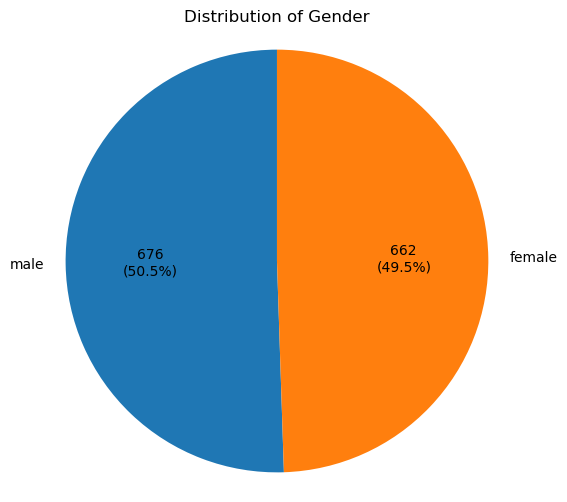

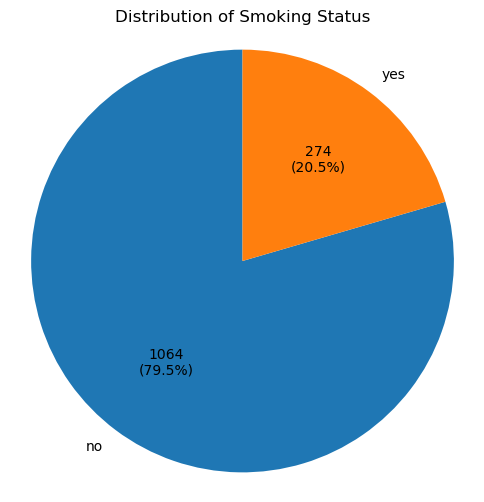

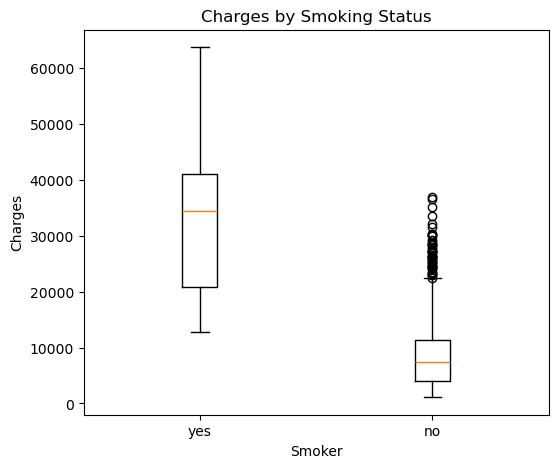

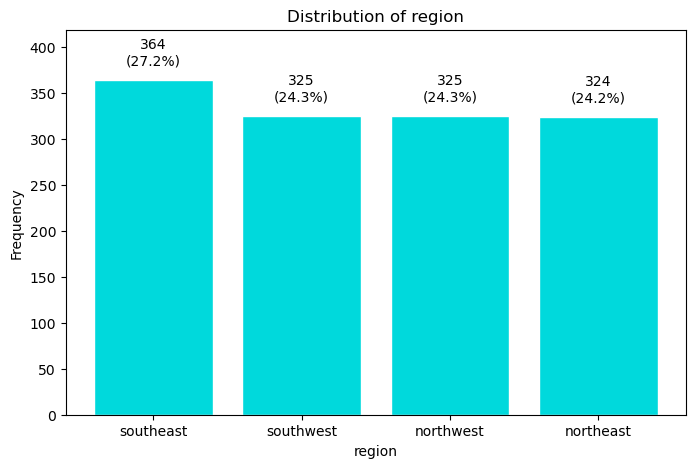

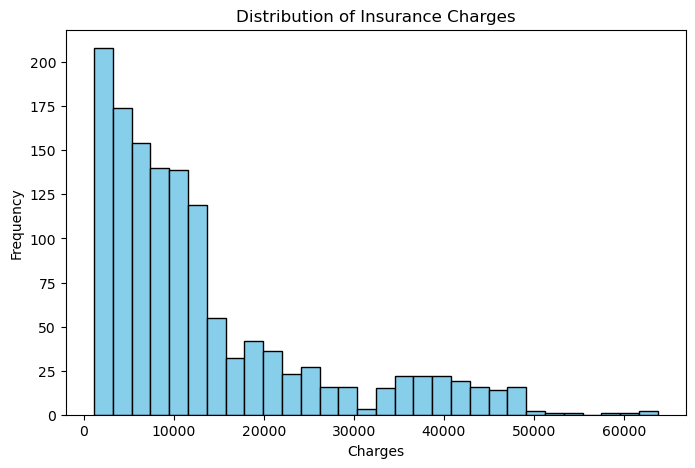

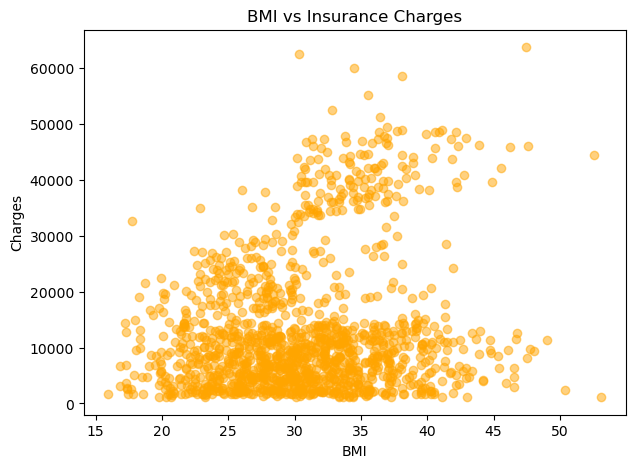

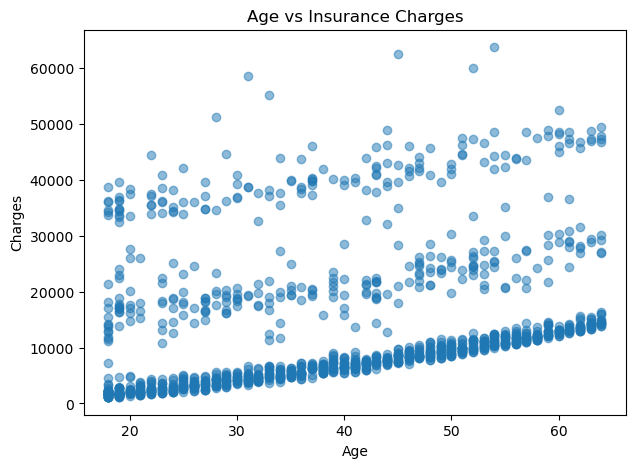

In [3]:
Insurance = pd.read_csv("https://raw.githubusercontent.com/adc-trust-ai/trust-free/refs/heads/main/notebooks/data/insurance.csv")
Insurance_X = Insurance.iloc[:,:-1]
Insurance_y = Insurance.iloc[:,-1]
n,p = np.shape(Insurance_X)
print(n,p)
print(Insurance.head())
Insurance.isnull().values.any() #check if there are any NaNs
# Quick summary for numeric variables
Insurance.describe()
# Complementary plotting for discrete ones
gender_counts = Insurance['sex'].value_counts()
total = gender_counts.sum()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct=lambda pct: f"{int(round(pct*total/100))}\n({pct:.1f}%)",
    startangle=90
)
plt.title("Distribution of Gender")
plt.axis("equal")
plt.show()

smoking_counts = Insurance['smoker'].value_counts()
total = smoking_counts.sum()

plt.figure(figsize=(6,6))
plt.pie(
    smoking_counts,
    labels=smoking_counts.index,
    autopct=lambda pct: f"{int(round(pct*total/100))}\n({pct:.1f}%)",
    startangle=90
)
plt.title("Distribution of Smoking Status")
plt.axis("equal")
plt.show()


plt.figure(figsize=(6,5))
categories = Insurance['smoker'].unique()
data_to_plot = [Insurance[Insurance['smoker']==cat]['charges'] for cat in categories]

plt.boxplot(data_to_plot, labels=categories)
plt.title("Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

def plot_categorical_bar(df, column, figsize=(8,5), color='#00d9dc', edgecolor='white'):
    """
    Plots a bar chart for a categorical column with counts and percentages on top.

    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe containing the column.
    column : str
        The name of the categorical column to plot.
    figsize : tuple
        Size of the figure.
    color : str
        Color of the bars (default: teal)
    edgecolor : str
        Edge color of the bars.
    """
    counts = df[column].value_counts()
    total = counts.sum()
    
    plt.figure(figsize=figsize)
    bars = plt.bar(counts.index, counts.values, color=color, edgecolor=edgecolor)
    
    for bar, count in zip(bars, counts.values):
        pct = count / total * 100
        plt.text(
            bar.get_x() + bar.get_width()/2,
            count + total*0.01,
            f"{count}\n({pct:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=10
        )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.ylim(0, max(counts.values)*1.15)
    plt.show()

plot_categorical_bar(Insurance, 'region') 

# Some more plotting
plt.figure(figsize=(8,5))
plt.hist(Insurance['charges'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(Insurance['bmi'], Insurance['charges'], alpha=0.5, color="orange")
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(Insurance['age'], Insurance['charges'], alpha=0.5)
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

Key observations:
- Charges tend to be higher for smokers.
- Charges seem to correlate positively with both BMI and age, but the raw signal is noisy.
- Extreme BMI values ($>$45) exist but could be realistic, not necessarily errors.

## Data Preprocessing 🔧

The dataset is already in good shape, with no missing values to handle.  

We still need a few preprocessing steps, such as creating a train–test split and applying one-hot encoding to categorical variables. These steps are required for standard models like Random Forest, XGBoost, and Lasso — but not for **TRUST**, which can natively handle categorical features and missing values without extra preprocessing.  

In [4]:
# Make train (70%) - test (30%) split (note: I always use the same seed in all my works)
X_train, X_test, y_train, y_test = train_test_split(Insurance_X, Insurance_y, test_size=0.3, random_state=123)

X_1Hot_enc = pd.get_dummies(Insurance_X, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
X_train_1Hot_enc, X_test_1Hot_enc, y_train, y_test = train_test_split(X_1Hot_enc, Insurance_y, test_size=0.3, random_state=123)
scaler = StandardScaler() #only strictly needed for Lasso, but doesn't hurt to do it for all models
X_train_1Hot_enc_scaled = scaler.fit_transform(X_train_1Hot_enc)
X_test_1Hot_enc_scaled = scaler.transform(X_test_1Hot_enc)

## Fit a TRUST Model 🤖

Fitting a TRUST model is straightforward.  

For maximum interpretability, we set the maximum tree depth to 1 (giving a simple 2-leaf tree) and provide the indices of the categorical variables in the dataset.  

Everything else is handled automatically by **trust-free**.

As we will see, this extremely simple architecture will be enough!

In [5]:
# Instantiate and fit your model
model = TRUST(max_depth = 1)
model.fit(X_train, y_train, catvar=[1,4,5])

# Predict and print results
y_pred_trust = model.predict(X_test)
print("\nPredictions:", np.round(y_pred_trust[:5]))
print("True y values:", np.round(y_test.values[:5]))
r2_trust = r2_score(y_test, y_pred_trust)
rmse_trust = root_mean_squared_error(y_test, y_pred_trust)
print(f"TRUST R²: {r2_trust:.4f}, RMSE: ${rmse_trust:.2f}")

***** TRUST: Transparent, Robust & Ultra-Sparse Trees [v1.1.2] *****
***** Copyright (c) 2025 Albert Dorador Chalar. All rights reserved. *****
0 missing values.
Proceeding to train a Relaxed Lasso Tree with requested max depth of 1.

Predictions: [13029.  6517. 38044.  7107. 13592.]
True y values: [ 9801.  4668. 34839.  5125. 12143.]
TRUST R²: 0.8853, RMSE: $4048.73


## Visualize the TRUST Tree 🌲

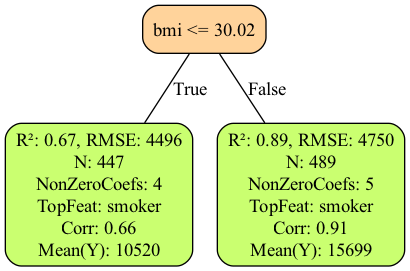

In [6]:
model.plot_tree("Insurance")

The trust-free model splits at **BMI $\leq$ 30**, which *coincides* with the clinical obesity threshold defined by the [World Health Organization](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight).

<table>
<tr>
  <td>
    <table border="1">
      <caption>Left Leaf</caption>
      <tr><th>Feature</th><th>Estimate</th><th>P-value</th></tr>
      <tr><td>Intercept</td><td>-10484.80</td><td>5.614857e-08</td></tr>
      <tr><td>age</td><td>270.48</td><td>1.329491e-50</td></tr>
      <tr><td>sex</td><td>0</td><td>1</td></tr>
      <tr><td>bmi</td><td>125.02</td><td>0.08</td></tr>
      <tr><td>children</td><td>478.19</td><td>6.339510e-03</td></tr>
      <tr><td>smoker</td><td>0.54</td><td>1.084861e-81</td></tr>  
    </table>
  </td>
  <td>
    <table border="1">
      <caption>Right Leaf</caption>
      <tr><th>Feature</th><th>Estimate</th><th>P-value</th></tr>
      <tr><td>Intercept</td><td>-7128.12</td><td>0.18</td></tr>
      <tr><td>age</td><td>255.98</td><td>3.024951e-51</td></tr>
      <tr><td>sex</td><td>-0.82</td><td>0.03</td></tr>
      <tr><td>bmi</td><td>116.87</td><td>0.03</td></tr>
      <tr><td>children</td><td>589.81</td><td>1.040272e-03</td></tr>
      <tr><td>smoker</td><td>1.39</td><td>5.714231e-230</td></tr>
    </table>
  </td>
</tr>
</table>

Note: The coefficients for sex and smoker must be interpreted relative to their encodings, which are based on the average charges of each category in the training data:

| sex     | sex_encoded |
|---------|-------------|
| female  | 12643.42    |
| male    | 13802.50    |


| smoker | smoker_encoded |
|--------|----------------|
| no     | 8495.85        |
| yes    | 32425.01       |


Key insights:
1. In all cases, **charges tend to *increase*** for:
   - **Older** patients 👵🏻👴🏻: each additional year is associated with $\$$256-$\$$270 more
   - **Heavier** patients ⚖️: each additional BMI point is associated with $\$$117-$\$$125 more
   - Individuals with **more children** covered by health insurance 👧👶: each additional child adds $\$$478-$\$$590
2. For clinically *obese* individuals (BMI > 30):
   - **Sex** becomes a relevant factor 👩/👨: *women* tend to be charged $\$$950 more than men (on average) 
   - **Smoking** matters nearly *3 times more* 🚬🚬🚬: smokers pay on average over $\$$33,000 more compared to non-smokers, vs. $\$$13,000 in the non-obese group

Takeaway 👉: **trust-free** not only rediscovers well-known medical risk factors on its own, but also pinpoints their interaction: obesity amplifies the financial penalty of smoking.

As we can see, this sparse structure provides **full interpretability**... while matching ensemble performance (!), as we will see later.


## Feature Importance (Ghost Variable Method) 📈

Next we will discover how important each variable is for our model. We use the Ghost Variable Method (Delicado and Peña, 2023), which is a fast and accurate way to measure feature importance conditional on the rest of features included in the model. That is, we measure how **"irreplaceable"** each feature in our model is.

***** Ghost Guide Variable Importance Scoring *****


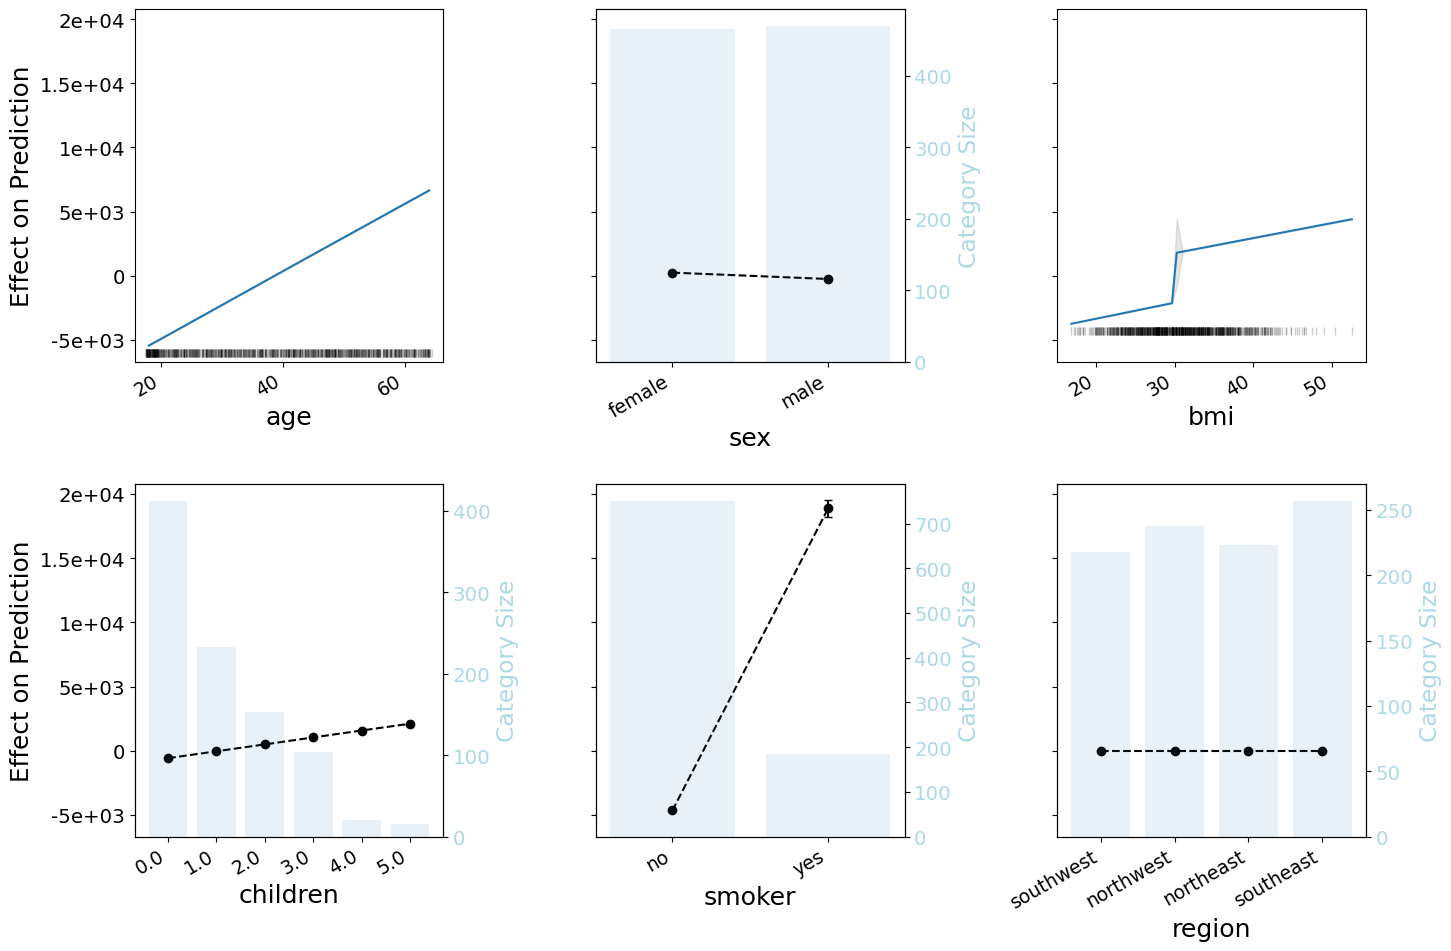

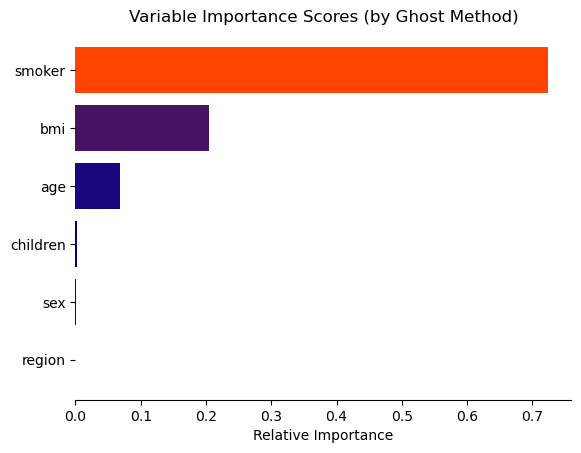

***** Comprehensive Analysis of Model Variable Importance *****
          Features with largest Kendall correlation with target
smoker                                                 0.53    
age                                                    0.49    
children                                               0.12    
bmi                                                    0.11    
region                                                 0.05    
Important variables in isolation but less so given the rest:
[]
(Might be strongly correlated with 1 or more covariates in the model)
Important variables given the rest of the covariates in the model, but found less important based on their marginal correlation:
[]
Important variables both marginally and conditionally:
['smoker']
Less important variables both marginally and conditionally:
['sex', 'region']


,Importance
smoker,0.72
bmi,0.20
age,0.07
children,0.00
sex,0.00
region,0.00


In [7]:
model.varImp(X_test, y_test, model, corAnalysis=True, filename="Insurance")

**Insight:** Smoking is by far the most important factor, followed by BMI and age. All other features are negligible.

## Explaining an Individual Prediction 🔍

Next, let’s zoom in on a **single prediction** to see how TRUST explains its decisions.  
This capability — **unique to trust-free** — is critical in domains like healthcare and finance, where every model decision must be *transparent* and *justifiable*.  

Consider the **3rd test observation**:  

- **27-year-old woman** 👩 
- **Smoker** 🚬  
- **Obese** (BMI > 30) ⚖️  
- **No children** ❌👧👶

**trust-free** predicts an **astronomical health insurance charge of \$38,044.35**.  
At first glance, this seems surprising: *she’s young and has no dependents — shouldn’t her expected cost be lower?*  

Let’s break down exactly **why trust-free assigns such a high charge**.  

***** Selected Instance Prediction Explanation *****
Observed feature values (unstandardized):
age              27.0
sex            female
bmi              31.4
children          0.0
smoker            yes
region      southwest

Categorical variables: ['sex', 'smoker', 'region']

Feature values of the training instance with the largest predicted response:
age              64.0
sex            female
bmi              31.3
children          2.0
smoker            yes
region      southwest

Feature values of the training instance with the smallest predicted response:
age              19.0
sex              male
bmi             17.48
children          0.0
smoker             no
region      northwest

Decision rules used (root-to-leaf path):
bmi > 30.02


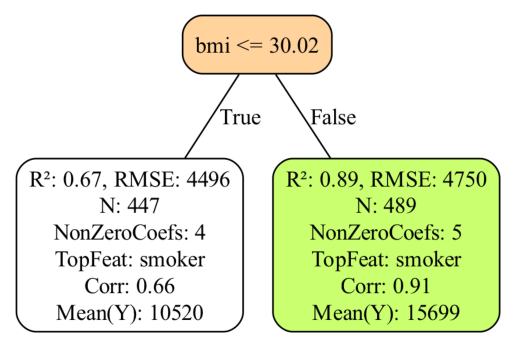


Showing destandardized regression coefficients
Estimated nonzero Relaxed Lasso coefficients:
             Estimate  Std. Error  t value        P(>|t|) Signif.
[Intercept]  -7128.12     5301.10    -1.34   1.793698e-01        
age            255.98       15.04    17.02   3.024951e-51     ***
sex             -0.82        0.38    -2.17   3.077699e-02       *
bmi            116.87       54.58     2.14   3.274862e-02       *
children       589.81      178.76     3.30   1.040272e-03      **
smoker           1.39        0.02    61.29  5.714231e-230     ***
*Note 1: Estimates are only approximately Gaussian in Relaxed Lasso regression.
*Note 2: p-values above not adjusted for variable selection, multiplicity or split search.
**Estimates for categorical variables correspond to their encoded values.
--- P(>|t|) signif. codes ---
[0-0.001): '***', [0.001-0.01): '**', [0.01-0.05): '*', [0.05-0.1): '.', else: ' '. >0.5: (name)

Target encoding for categorical variable: sex
   sex  sex_encoded
femal

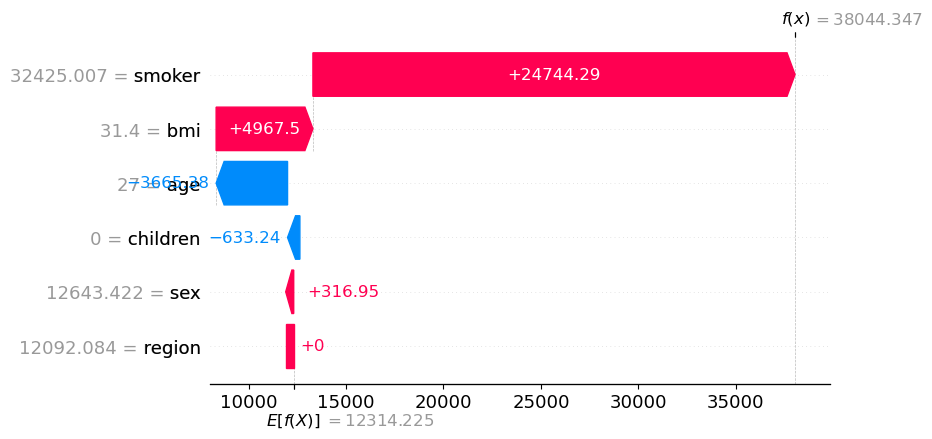

 prediction  avg pred.   smoker    bmi      age  children    sex  region
   38044.35   12314.23 24744.29 4967.5 -3665.38   -633.24 316.95     0.0

--- Terminal node metrics ---
RMSE: 4749.89. Adj. R²: 0.89. F-stat: 819.5, p-value: 1.11e-16.
Actual charges value: 34838.87
Predicted charges value: 38044.35, difference: 9.2%
Average charges value in leaf: 15698.61, difference: -54.94%

<<< Summary >>>
-The predicted value of 38044.35 (very large) is mainly due to sex being female, smoker being yes, intermediate values of bmi and children, and a small value of age. Note: although this configuration yielded a very large predicted value, it is not necessarily the only configuration capable of doing so.
-Compared to the training instance with largest predicted response, this instance has smaller age, the same sex, larger bmi, smaller children and the same smoker. On the other hand, compared to the training instance with smallest predicted response, this instance has larger age, sex female ins

In [8]:
model.explain(X_test.iloc[2,:], y_pred_trust[2], actual=y_test.values[2], filename="Insurance") 

We see that although this individual was young and had no children, the combined effect of being a **smoker** and **clinically obese** turned out to be far more significant than one might expect.  

The *true* insurance charge for this person was $\$$34,838.87, meaning the **trust-free** prediction of $\$$38,044.35, as large as it seemed, was off by only *9\%* — remarkably accurate given the model’s extreme simplicity.  

## TRUST vs Other Models 🎯

In this section we will test other popular models and see how they compare to TRUST in terms of accuracy and interpretability.

The alternative models we consider are:
- Decision Tree 🌲
- Random Forest 🌲🌲...🌲
- XGBoost 🌳...🌲...🌴
- Lasso 𓎤

Because there's no honor in winning an unfair fight, we will ***heavily tune the competing models*** to give them the best possible chance to match or exceed **trust-free** in accuracy (even though the latter is used right out of the box).

In [9]:
%%time

# Function to count leaves in XGBoost trees
def count_xgboost_leaves(model):
    # Get tree dumps
    trees = model.get_booster().get_dump()
    total_leaves = 0
    for tree in trees:
        # Count lines that represent leaves (lines with "leaf=")
        leaves_in_tree = len([line for line in tree.split('\n') if 'leaf=' in line])
        total_leaves += leaves_in_tree
    return total_leaves

from sklearn.model_selection import GridSearchCV

models_and_params = {
    "Decision Tree": {
        "model": DecisionTreeRegressor(),
        "params": {
            'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20],
            'min_samples_split': [2, 3, 4, 5, 10, 20]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=123),
        "params": {
            'n_estimators': [100, 250, 500],
            'max_depth': [2, 4, 6, 8, 10, 15],
            'min_samples_split': [2, 3, 4, 5, 10, 20]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=123),
        "params": {
            'n_estimators': [100, 250, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 4, 6, 8, 10, 15],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    },
    "Lasso": {
        "model": Lasso(),
        "params": {
            'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
        }
    }  
}

# Loop through models for hyperparameter tuning
best_estimators = {}
results = []

for model_name, model_info in models_and_params.items():
    print(f"Tuning {model_name}...")
    
    # Initialize GridSearchCV
    search = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        scoring='neg_mean_squared_error',
        cv=10,
        n_jobs=-1
    )
    
    # Fit the model
    search.fit(X_train_1Hot_enc_scaled, y_train)
    
    # Best estimator and parameters
    best_estimators[model_name] = search.best_estimator_
    best_params = search.best_params_
    
    if model_name == "Decision Tree":
      num_leaves = search.best_estimator_.get_n_leaves()
      print(f'#leaves in best DT = {num_leaves}')
    elif model_name == "Random Forest":
      num_trees = search.best_estimator_.n_estimators
      num_leaves = sum(tree.get_n_leaves() for tree in search.best_estimator_.estimators_)
      print(f'#trees in best RF = {num_trees}')
      print(f'#leaves in best RF = {num_leaves}')
    elif model_name == "XGBoost":
      num_trees = search.best_estimator_.n_estimators
      num_leaves = count_xgboost_leaves(search.best_estimator_)
      print(f'#trees in best XGB = {num_trees}')  
      print(f'#leaves in best XGB = {num_leaves}')
    elif model_name == "Lasso":
      num_nonzero_coefs = np.sum(search.best_estimator_.coef_ != 0)
      print(f'#nonzero coefs in best Lasso = {num_nonzero_coefs}') 
    
    # Evaluate on the test set
    y_pred = search.best_estimator_.predict(X_test_1Hot_enc_scaled)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append({
        "Model": model_name,
        "Best Parameters": best_params,
        "RMSE": rmse,
        "R² Score": r2
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display results
print(results_df)

Tuning Decision Tree...
#leaves in best DT = 28
Tuning Random Forest...
#trees in best RF = 250
#leaves in best RF = 4000
Tuning XGBoost...
#trees in best XGB = 250
#leaves in best XGB = 988
Tuning Lasso...
#nonzero coefs in best Lasso = 6
           Model                                    Best Parameters  \
0  Decision Tree          {'max_depth': 5, 'min_samples_split': 20}   
1  Random Forest  {'max_depth': 4, 'min_samples_split': 4, 'n_es...   
2        XGBoost  {'colsample_bytree': 0.8, 'learning_rate': 0.0...   
3          Lasso                                     {'alpha': 100}   

          RMSE  R² Score  
0  4481.242539  0.859432  
1  4065.846227  0.884285  
2  4083.012817  0.883305  
3  5822.572375  0.762688  
CPU times: user 1.97 s, sys: 537 ms, total: 2.51 s
Wall time: 58.9 s


| Model           | R² (Test)| #Trees | #Leaves or Coefs |
|-----------------|----------|--------|------------------|
| Decision Tree   | 0.86     | 1      | 28               |
| Random Forest   | 0.88     | 250    | 4000             |
| XGBoost         | 0.88     | 250    | 988              |
| Lasso           | 0.76     | "1"    | 6                |
| **trust-free**  | **0.89** | 1      | 2 or 4+5         |

> 🚨 **trust-free** not only achieves full interpretability with only two leaves and sparse linear models, but also **slightly exceeds the predictive performance** of even the fully tuned (black-box) ensemble models!

> 🚨 Locally, it remains extremely simple to interpret — even more so than a Lasso model (!) — while delivering **ensemble-level accuracy and beyond**.

## Takeaways 💡

1. **trust-free** achieves (slightly better than) **ensemble-level performance** on a widely used dataset.  
2. Automatically discovers **clinically meaningful splits** (e.g., BMI = 30).  
3. Produces **sparse, interpretable linear models** in each leaf, capturing distinct subgroups.  
4. Intuitive **feature importance**.  
5. Automatically generates detailed **individual prediction explanations** on the fly.

> **Food for thought:** On this dataset, **trust-free** revealed that the seemingly arbitrary BMI threshold of 30 — as defined by the World Health Organization — is actually highly meaningful when predicting health insurance charges, reflecting the severity of health conditions.


## Next Steps ➡️

### Try it yourself! 🚀

- Install **trust-free** (if you haven't yet): `pip install trust-free`  
- Reproduce these results using the full notebook in this repo.  
- Explore other datasets to see **trust-free** automatically discover sparse, interpretable models with high predictive performance.

### Contact 📧

We hope this tutorial was useful. Now, with the **trust-free** package under your belt, you’ll be ready to tackle with confidence any regression problem thrown your way!

Your feedback helps us improve ❤️ Please share your comments, questions, or suggestions here: [2-minute Feedback Form](https://docs.google.com/forms/d/1a02AW5dRy6HJj5WhQKWfLUptCQnT_WfSnUrLb7Jq2C0/edit). To report any issues, please open an issue on the project's [GitHub page](https://github.com/adc-trust-ai/trust-free).

👉 Want to go further? Check out our [Project page](https://adc-trust-ai.github.io/trust/) and our [GitHub repository](https://github.com/adc-trust-ai/trust-free) to stay up to date with the latest releases.

Lastly, feel free to connect with me on [LinkedIn](https://www.linkedin.com/in/albertdorador/) to stay updated with our latest research and software developments on interpretable ML.

In [10]:
# Session info

import sys, platform, sklearn, matplotlib, xgboost

print("Python:", sys.version)
print("OS:", platform.platform())
print("trust-free:", TRUST().__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("xgboost:", xgboost.__version__)

Python: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:52:34) [Clang 18.1.8 ]
OS: macOS-15.6.1-arm64-arm-64bit
trust-free: 1.1.2
pandas: 2.3.2
numpy: 1.26.4
scikit-learn: 1.7.1
matplotlib: 3.10.5
xgboost: 3.0.4
